In [21]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [22]:
import os
import glob

data_dir = os.path.join('.', 'BearingData')
mat_files = glob.glob(os.path.join(data_dir, '*.mat'))

In [23]:
def extract_features(df):
    features = pd.DataFrame(index=df.index)

    for col, prefix in [('vibration', 'vib'), ('tach', 'tach')]:
        series = df[col]  # Series of 1D arrays

        mean      = series.apply(lambda v: np.mean(v))
        std       = series.apply(lambda v: np.std(v))
        rms       = series.apply(lambda v: np.sqrt(np.mean(v**2)))
        peak2peak = series.apply(lambda v: np.max(v) - np.min(v))
        peak      = series.apply(lambda v: np.max(v))
        energy    = series.apply(lambda v: np.sum(v**2))

        features[f"{prefix}_mean"]      = mean
        features[f"{prefix}_std"]       = std
        features[f"{prefix}_skewness"]  = series.apply(
            lambda v: np.mean((v - np.mean(v))**3) / (np.std(v)**3)
        )
        features[f"{prefix}_kurtosis"]  = series.apply(
            lambda v: np.mean((v - np.mean(v))**4) / (np.std(v)**4)
        )
        features[f"{prefix}_peak2peak"] = peak2peak
        features[f"{prefix}_rms"]       = rms
        features[f"{prefix}_crest_factor"] = peak / rms
        features[f"{prefix}_energy"]    = energy

    return features


In [24]:
def read_data(filepath):
    mat = loadmat(filepath)
    vibration = mat['vibration'].flatten()
    tach = mat['tach'].flatten()

    filename = os.path.basename(filepath)
    match = re.search(r'(\d{8}T\d{6}Z)', filename)
    if match:
        date = pd.to_datetime(match.group(1), format='%Y%m%dT%H%M%SZ')
    else:
        date = pd.NaT

    return pd.DataFrame({
        'Date': [date],
        'vibration': [vibration],
        'tach': [tach]
    })

In [25]:
records = [read_data(f) for f in mat_files]
data = pd.concat(records, ignore_index=True)
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)
data = data[['vibration', 'tach']]

data.head()

,vibration,tach
Date,,
2013-03-07 01:57:46,"[-0.41461882, 0.17249019, -0.40377742, -0.7735...","[0.00850752, 0.02515552, 0.04181376, 0.0584633..."
2013-03-08 02:34:21,"[0.47406808, 0.5946402, 1.40306878, 1.37704206...","[0.00100896, 0.01764928, 0.03430272, 0.0509516..."
2013-03-09 02:33:43,"[1.03988814, -0.51729834, 0.66616142, 1.033624...","[0.0164624, 0.03308832, 0.04970848, 0.06634016..."
2013-03-10 03:01:02,"[4.64931059, 5.18905449, 1.3001678, -1.9041850...","[0.00610944, 0.02263584, 0.03915104, 0.0556736..."
2013-03-11 03:00:24,"[1.95252204, 2.40152335, 1.93071616, 0.9849058...","[0.007984, 0.02385248, 0.039712, 0.05558432, 0..."


In [26]:
features = extract_features(data)
features.head()

,vib_mean,vib_std,vib_skewness,vib_kurtosis,vib_peak2peak,vib_rms,vib_crest_factor,vib_energy,tach_mean,tach_std,tach_skewness,tach_kurtosis,tach_peak2peak,tach_rms,tach_crest_factor,tach_energy
Date,,,,,,,,,,,,,,,,
2013-03-07 01:57:46,0.346052,2.270481,0.003870,2.995612,21.621068,2.296702,4.914735,3.090718e+06,20.364079,11.753166,-0.000865,1.799625,40.689990,23.512393,1.730938,1.352229e+06
2013-03-08 02:34:21,0.244092,2.062146,0.003010,3.019457,19.309907,2.076542,4.912863,2.526572e+06,20.064301,11.586410,-0.000408,1.800114,40.120764,23.169400,1.731671,1.294276e+06
2013-03-09 02:33:43,0.218729,2.103553,-0.001029,3.022396,21.474075,2.114894,5.214330,2.620761e+06,20.477625,11.816342,-0.000586,1.799279,40.905935,23.642315,1.730896,1.377834e+06
2013-03-10 03:01:02,0.213717,2.008063,0.001477,3.041457,19.520002,2.019404,5.286041,2.389443e+06,20.343548,11.741138,-0.000771,1.799980,40.649641,23.488598,1.730872,1.357769e+06
2013-03-11 03:00:24,0.215185,2.060562,0.001012,3.044474,21.216959,2.071768,5.005767,2.514967e+06,20.131019,11.618124,0.002156,1.805190,40.285980,23.243036,1.733593,1.353838e+06


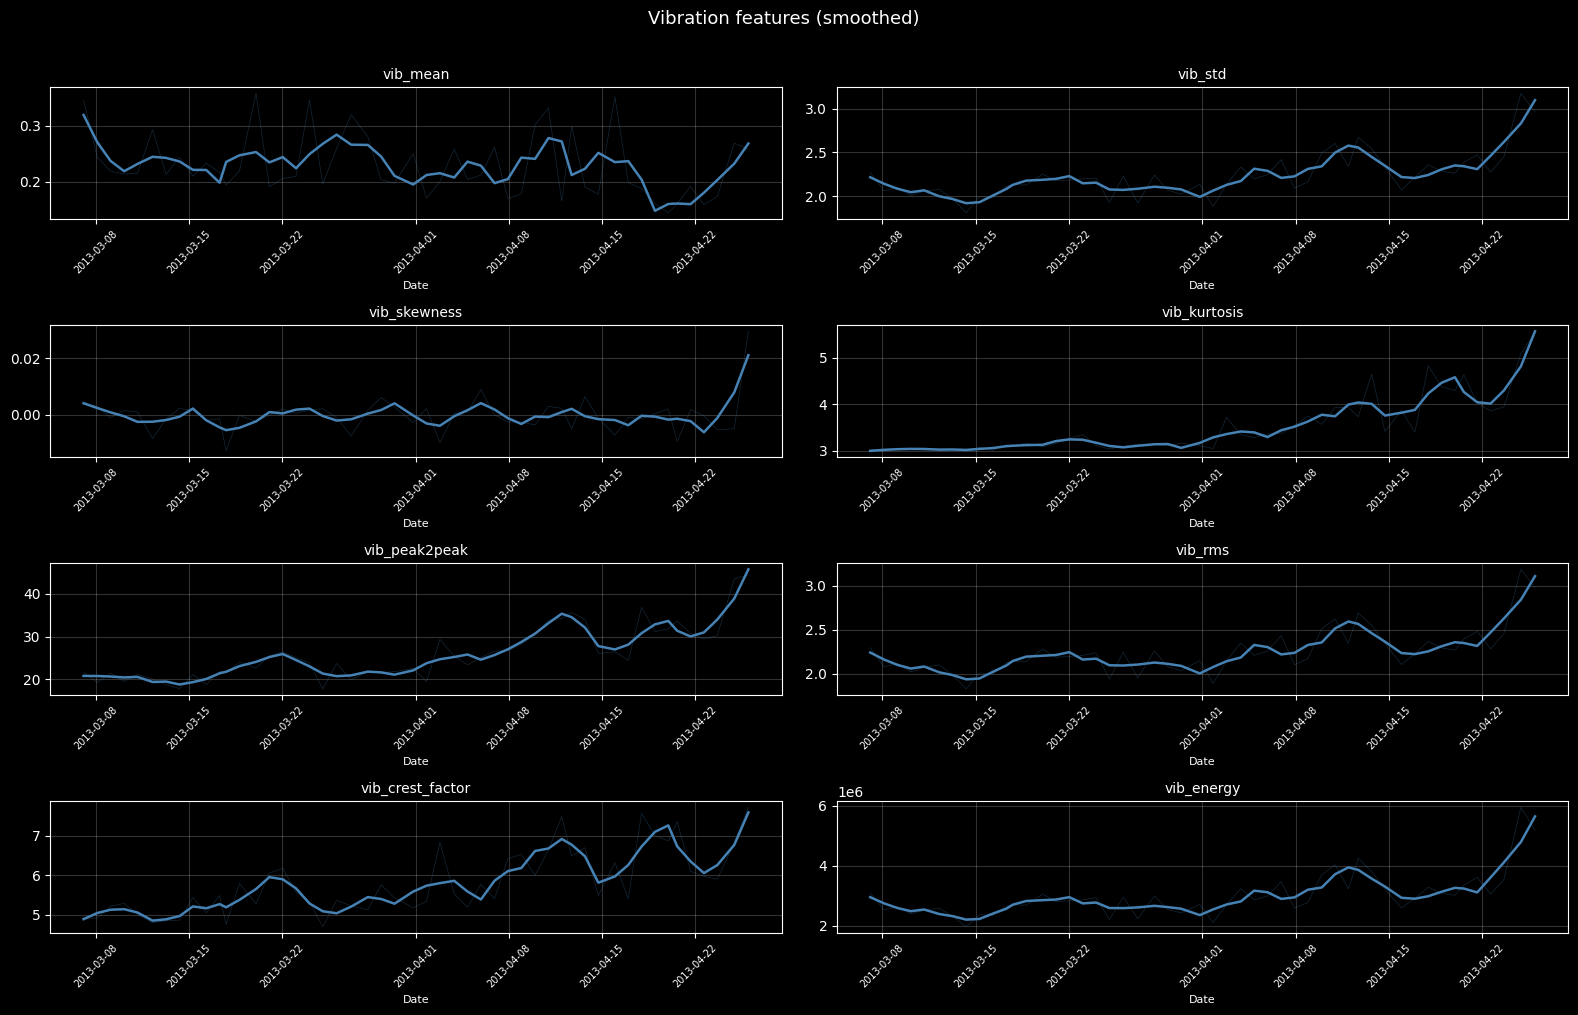

In [27]:
from scipy.signal import savgol_filter

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 10))
axes = axes.flatten()

vib_cols = [col for col in features.columns if col.startswith('vib')]

for i, col in enumerate(vib_cols):
    ax = axes[i]
    raw = features[col]
    win_len = min(7, len(raw) if len(raw) % 2 == 1 else len(raw) - 1)
    smoothed = savgol_filter(raw, window_length=win_len, polyorder=2)

    ax.plot(features.index, raw, lw=0.5, alpha=0.3, color='steelblue')
    ax.plot(features.index, smoothed, lw=1.8, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.2)

for j in range(len(vib_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Vibration features (smoothed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

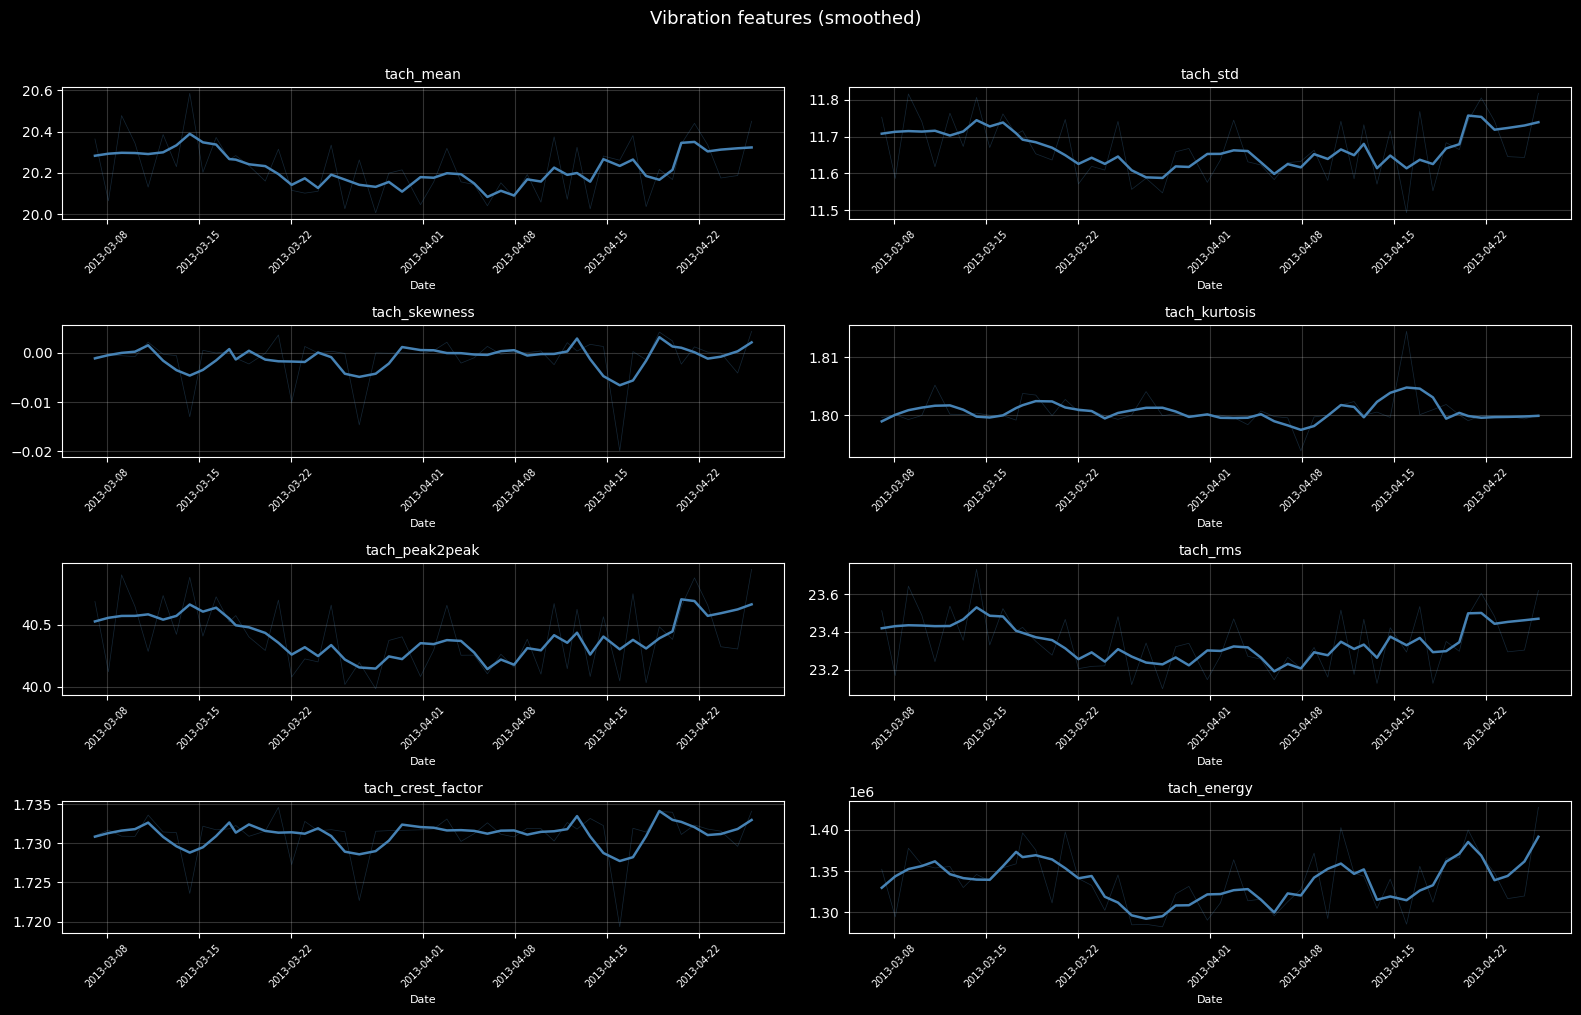

In [28]:
from scipy.signal import savgol_filter

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 10))
axes = axes.flatten()

tach_cols = [col for col in features.columns if col.startswith('tach')]

for i, col in enumerate(tach_cols):
    ax = axes[i]
    raw = features[col]
    win_len = min(7, len(raw) if len(raw) % 2 == 1 else len(raw) - 1)
    smoothed = savgol_filter(raw, window_length=win_len, polyorder=2)

    ax.plot(features.index, raw, lw=0.5, alpha=0.3, color='steelblue')
    ax.plot(features.index, smoothed, lw=1.8, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.2)

# hide unused subplots if tach_cols < 6
for j in range(len(tach_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Vibration features (smoothed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# ── Step 1: Smooth all features (causal moving mean, window=5) ──
features_smooth = features.copy()
for col in features.columns:
    features_smooth[col] = features[col].rolling(window=5, min_periods=1).mean()


/tmp/ipykernel_427090/3891560525.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


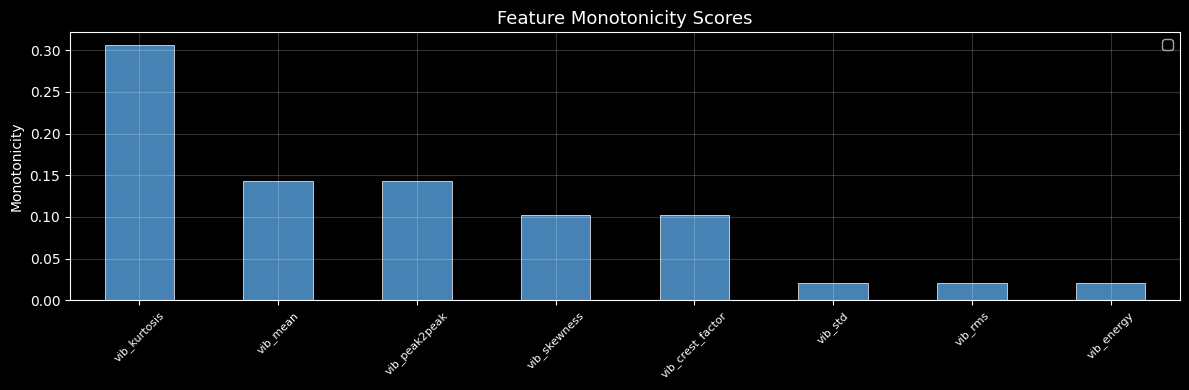

vib_kurtosis: 0.306
vib_mean: 0.143
vib_peak2peak: 0.143
vib_skewness: 0.102
vib_crest_factor: 0.102


In [58]:
# ── Step 2: Monotonicity ranking ──
def monotonicity(series):
    d = np.diff(series)
    return abs((d > 0).sum() - (d < 0).sum()) / len(d)

mono_scores = {col: monotonicity(features_smooth[col].values)
               for col in features_smooth.columns if col.startswith('vib')}
mono_df = pd.Series(mono_scores).sort_values(ascending=False)

# Bar plot of monotonicity scores
fig, ax = plt.subplots(figsize=(12, 4))
mono_df.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_title("Feature Monotonicity Scores", fontsize=13)
ax.set_ylabel("Monotonicity")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

threshold = 0.1
feature_cols = []
for col in mono_df.index:
    if mono_df[col] > threshold:
        feature_cols.append(col)
        print(f"{col}: {mono_df[col]:.3f}")

mono_scores = {col: score for col, score in mono_scores.items() if score >threshold}

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── MathWorks-style: fit PCA on training data only (first 40% = 20 days) ──
N_TRAIN = max(1, int(len(features) * 0.4))

# FIX: use the same smoothed features that were used for monotonicity selection
X_all = features_smooth[feature_cols].copy()
X_train = X_all.iloc[:N_TRAIN]

# Normalise using training mean/std only
mean_train = X_train.mean()
std_train  = X_train.std().replace(0, 1)  # guard against zero-std columns

X_all_norm   = (X_all   - mean_train) / std_train
X_train_norm = (X_train - mean_train) / std_train

# Fit PCA on training data, project all data onto PC1
pca = PCA()
pca.fit(X_train_norm)
score = X_all_norm.values @ pca.components_[0]  # PC1 scores for all days

print(f"Training days: {N_TRAIN}, Total days: {len(features)}")
print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")


Training days: 20, Total days: 50
PC1 explains 61.1% of variance


In [60]:
from scipy.signal import savgol_filter

# Smooth the PC1 score with causal rolling mean
score_smooth = pd.Series(score, index=features.index).rolling(window=5, min_periods=1).mean().values

# Ensure PC1 increases toward failure (flip if decreasing)
if np.corrcoef(np.arange(len(score_smooth)), score_smooth)[0, 1] < 0:
    score_smooth = -score_smooth

# Shift so day 1 = 0
healthIndicator = score_smooth - score_smooth[0]

# FIX: use the last observed score as the failure reference point,
# not a 3-sigma outlier threshold from the healthy training window.
# The 3-sigma boundary fires too early (early-anomaly, not end-of-life).
failure_score = healthIndicator[-1]  # score at the final observed day

# Optional alarm line: where signal first exceeds training noise
alarm_threshold = healthIndicator[:N_TRAIN].mean() + 3 * healthIndicator[:N_TRAIN].std()

print(f"Failure reference score (day {len(healthIndicator)}): {failure_score:.4f}")
print(f"Early-alarm threshold (3-sigma): {alarm_threshold:.4f}")


Failure reference score (day 50): 19.1556
Early-alarm threshold (3-sigma): 6.8265


In [61]:
# FIX: normalise against failure_score so HI = 1.0 only at the last observed day,
# not at the early-anomaly 3-sigma crossing.
HI = 1 - np.clip(healthIndicator / failure_score, 0, 1)


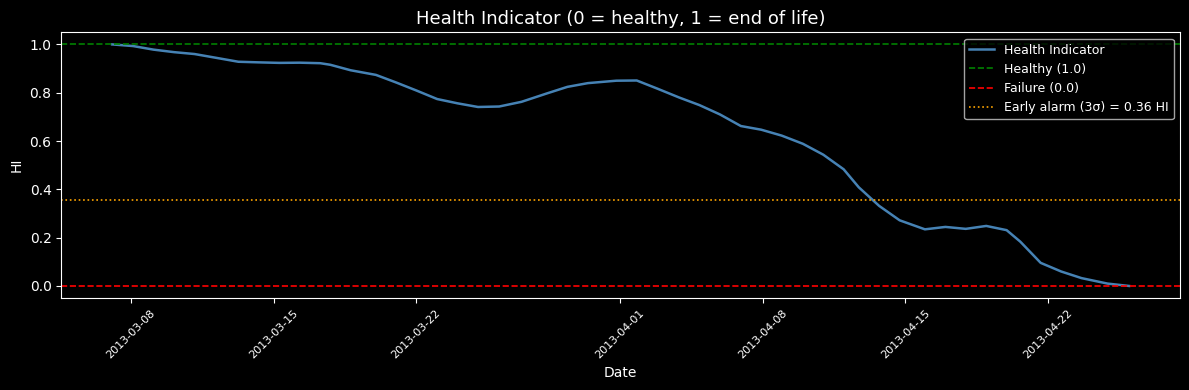

In [62]:
hi_series = pd.Series(HI, index=features.index, name="HealthIndicator")

plt.figure(figsize=(12, 4))
plt.plot(hi_series.index, hi_series.values, lw=1.8, color="steelblue", label="Health Indicator")
plt.axhline(y=1.0, color="green", linestyle="--", linewidth=1.2, label="Healthy (1.0)")
plt.axhline(y=0.0, color="red",   linestyle="--", linewidth=1.2, label="Failure (0.0)")
# Show where the early alarm fires relative to the full scale
alarm_hi = alarm_threshold / failure_score
plt.axhline(y=alarm_hi, color="orange", linestyle=":", linewidth=1.2,
            label=f"Early alarm (3σ) = {alarm_hi:.2f} HI")
plt.title("Health Indicator (0 = healthy, 1 = end of life)", fontsize=13)
plt.xlabel("Date", fontsize=10)
plt.ylabel("HI", fontsize=10)
plt.tick_params(axis="x", rotation=45, labelsize=8)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
